preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForQuestionAnswering LOAD REPORT from: Salesforce/blip-vqa-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 
text_encoder.embeddings.position_ids      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--- Visual Reasoning Results (BLIP-VQA) ---
Question: What is the animal doing?
AI Answer: no animal
------------------------------
Question: What color is the background?
AI Answer: blue
------------------------------
Question: Is there a person in the photo?
AI Answer: yes
------------------------------


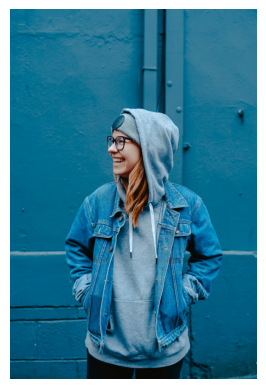

In [4]:
# 1. Install necessary libraries
!pip install transformers pillow requests

import torch
import requests
from PIL import Image
from transformers import BlipProcessor, BlipForQuestionAnswering
import matplotlib.pyplot as plt

# 2. Load the Processor and Model (Using BLIP-VQA)
# This model is specifically fine-tuned for the VQAv2 dataset
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base").to(device)

# 3. Select an Image to "Interview"
img_url = "https://images.unsplash.com/photo-1517841905240-472988babdf9" # Dog image
raw_image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')

# 4. Define your questions
questions = [
    "What is the animal doing?",
    "What color is the background?",
    "Is there a person in the photo?"
]

print(f"--- Visual Reasoning Results (BLIP-VQA) ---")

for question in questions:
    # Prepare inputs for the model
    inputs = processor(raw_image, question, return_tensors="pt").to(device)

    # Generate the answer
    out = model.generate(**inputs)
    answer = processor.decode(out[0], skip_special_tokens=True)

    print(f"Question: {question}")
    print(f"AI Answer: {answer}")
    print("-" * 30)

# 5. Display the image
plt.imshow(raw_image)
plt.axis("off")
plt.show()